In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("food_delivery_orders.csv")
df.head(10)

,order_date,city,restaurant_category,cuisine,order_value,discount_percent,delivery_time_min,rating,profit_per_order
0,2023-01-01,Karachi,Fine Dining,Continental,2768.0,25.0,36.2,4.5,95.0
1,2023-01-01,Karachi,Fine Dining,Steakhouse,4979.0,44.8,23.3,4.8,-437.0
2,2023-01-01,Karachi,Cloud Kitchen,Indian,4008.0,11.9,39.6,4.2,618.0
3,2023-01-01,Islamabad,Fine Dining,Steakhouse,3260.0,8.3,35.8,4.5,423.0
4,2023-01-01,Karachi,Fast Food,Pizza,435.0,13.5,29.4,4.8,53.0
5,2023-01-01,Islamabad,Dessert,Sweets,701.0,14.7,35.8,4.2,78.0
6,2023-01-01,Lahore,Dessert,Ice Cream,339.0,20.4,39.0,4.6,-112.0
7,2023-01-01,Faisalabad,Fast Food,Sandwiches,748.0,15.8,30.4,4.3,53.0
8,2023-01-02,Lahore,Cafe,Sandwiches,562.0,6.5,29.5,4.8,69.0
9,2023-01-02,Multan,Dessert,Cakes,150.0,28.7,49.7,4.2,-158.0


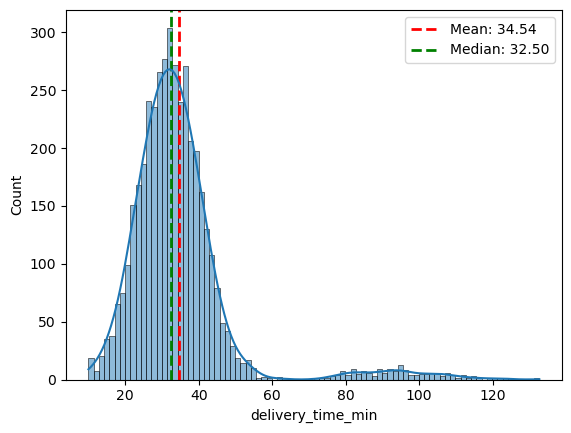

In [24]:
# task 1
data_mean=df['delivery_time_min'].mean()
data_median=df['delivery_time_min'].median()
plt.axvline(data_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {data_mean:.2f}')
plt.axvline(data_median, color='green', linestyle='--', linewidth=2, label=f'Median: {data_median:.2f}')
sns.histplot(data=df, x="delivery_time_min",kde=True)
plt.legend()
plt.show()

# Median is better number since numbers are skewed so median is better represenation of center

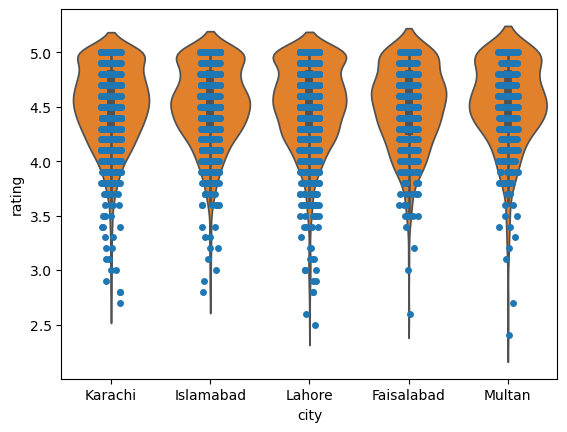

In [18]:
# task 2
sns.stripplot(x='city', y='rating', data=df)
sns.violinplot(x='city', y='rating', data=df)
plt.show()

# most inconsistent rating is of Multan because it has many 5 star rating, then lesser 4-5 star rating and then alot of 4 star, so ppl either love it or
# think its just fine 

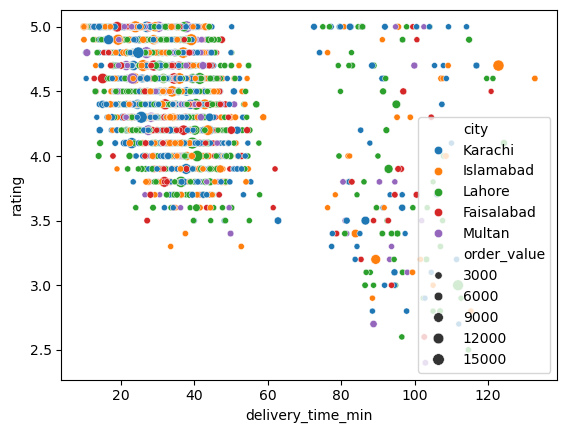

In [23]:
# task 3
sns.scatterplot(data=df, x='delivery_time_min', y='rating', hue='city',size='order_value')
plt.show()

# higher the order_value, the more priority it takes and gets delivered faster (besides a few outliers)

The pair with the biggest disagreement is: ('order_value', 'profit_per_order')
The difference between Pearson and Spearman is: 1.3303


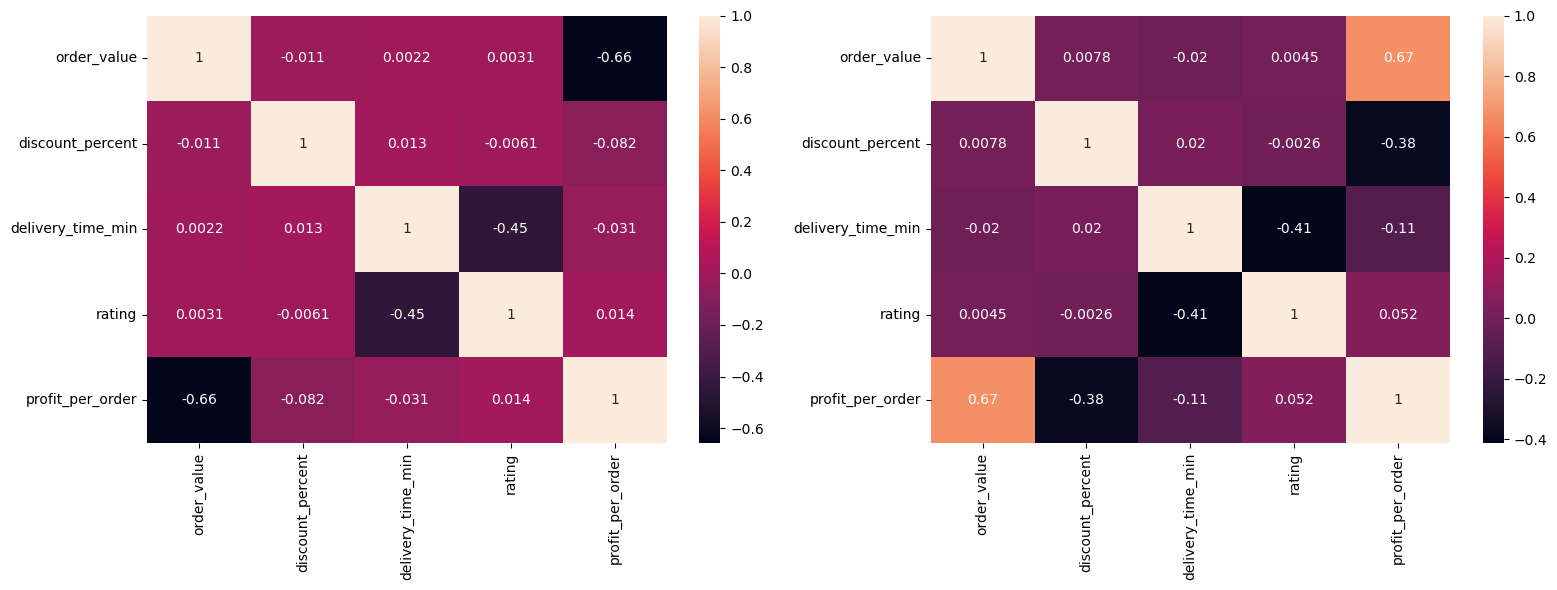

In [35]:
# task 4
numeric_df = df.select_dtypes(include=[np.number])
pearson_matrix = numeric_df.corr(method='pearson')
spearman_matrix = numeric_df.corr(method='spearman')

diff_matrix = (pearson_matrix - spearman_matrix).abs()

# Clear out the diagonal (self-correlation) so we don't look at a variable compared to itself
np.fill_diagonal(diff_matrix.values, 0)

# Find the pair with the maximum difference
max_diff = diff_matrix.max().max()
pair = diff_matrix.stack().idxmax()

print(f"The pair with the biggest disagreement is: {pair}")
print(f"The difference between Pearson and Spearman is: {max_diff:.4f}")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(pearson_matrix,ax=axes[0],annot=True)
sns.heatmap(spearman_matrix,ax=axes[1], annot=True)
plt.tight_layout()
plt.show()

# pearson method shows negative correlation between profit_per_order and order_value while spearman shows positive correlation

restaurant_category       Cafe  Cloud Kitchen    Dessert  Fast Food  \
city                                                                  
Faisalabad           67.295455      65.779748 -70.312281  20.222750   
Islamabad           -13.499649      57.011427 -27.884178  37.177258   
Karachi             -38.901838     136.745480  75.240260  15.375665   
Lahore               52.345680     137.614221  65.515000  10.618693   
Multan               60.137931     -82.783323  55.865385 -40.784432   
All                  14.648580      91.829915  31.277856  13.613870   

restaurant_category  Fine Dining        All  
city                                         
Faisalabad            293.695652  51.891636  
Islamabad             153.117851  35.491634  
Karachi               302.801418  74.101668  
Lahore                159.818290  71.552572  
Multan                285.181818  12.622372  
All                   228.922310  57.370067  


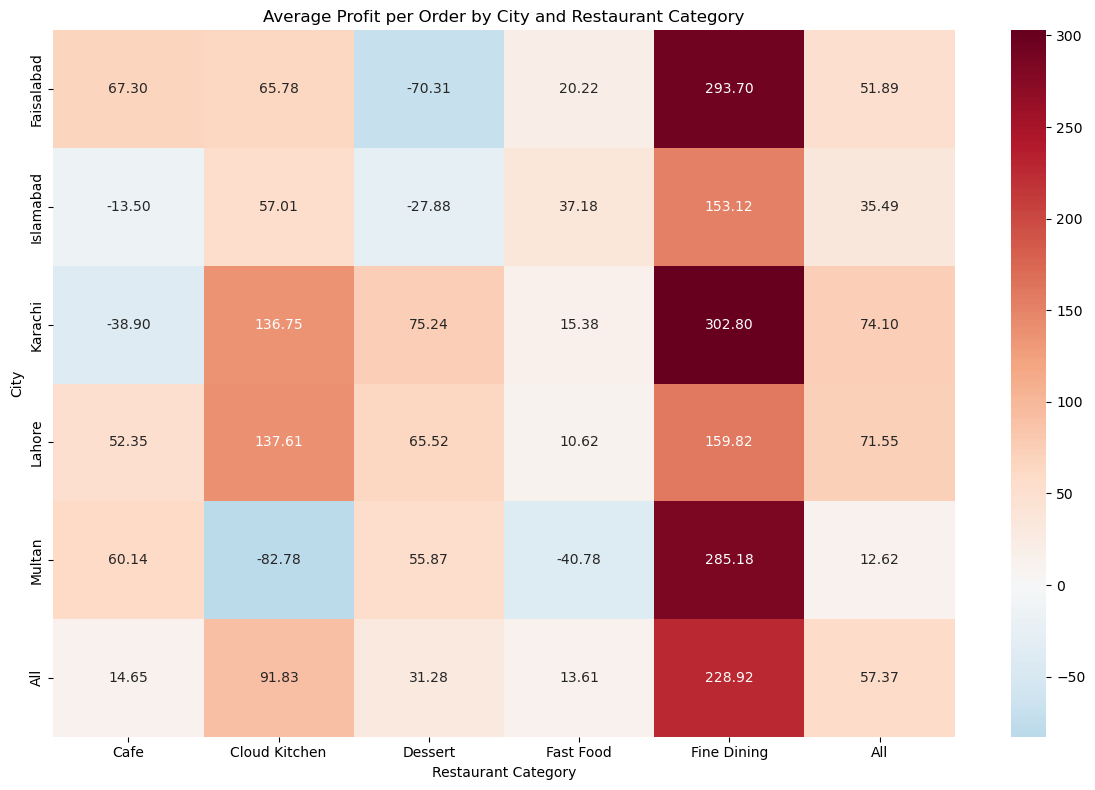

Most profitable combination: Karachi × Fine Dining
Average profit per order: 302.80


In [36]:
# task 5
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Layered aggregation
pivot = pd.pivot_table(
    df,
    values='profit_per_order',
    index='city',
    columns='restaurant_category',
    aggfunc='mean',
    margins=True
)

print(pivot)

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0
)

plt.title('Average Profit per Order by City and Restaurant Category')
plt.xlabel('Restaurant Category')
plt.ylabel('City')
plt.tight_layout()
plt.show()

# Most profitable city x category combination
combination = pivot.drop(index='All', errors='ignore').drop(columns='All', errors='ignore').stack().idxmax()

profit = pivot.loc[combination[0], combination[1]]

print(f"Most profitable combination: {combination[0]} × {combination[1]}")
print(f"Average profit per order: {profit:.2f}")

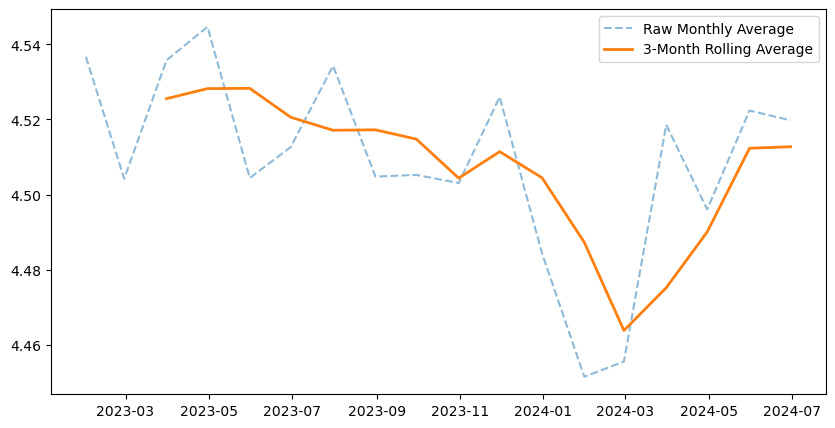

In [59]:
# task 6
df['order_date'] = pd.to_datetime(df['order_date'])

monthly_rating = df.set_index('order_date')['rating'].resample('ME').mean()
rolling_rating = monthly_rating.rolling(window=3).mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_rating.index, monthly_rating, label='Raw Monthly Average', alpha=0.5, linestyle='--')
plt.plot(rolling_rating.index, rolling_rating, label='3-Month Rolling Average', linewidth=2)

plt.legend()
plt.show()
#dotted line is the average rating per month the solid line is the rolling average 
#the dotted shows huge dips and noise between months but the solid line smoothes them out well 
#I would've said there is huge variance in the raw monthly line but the solid line shows the actual smoothed out rating average

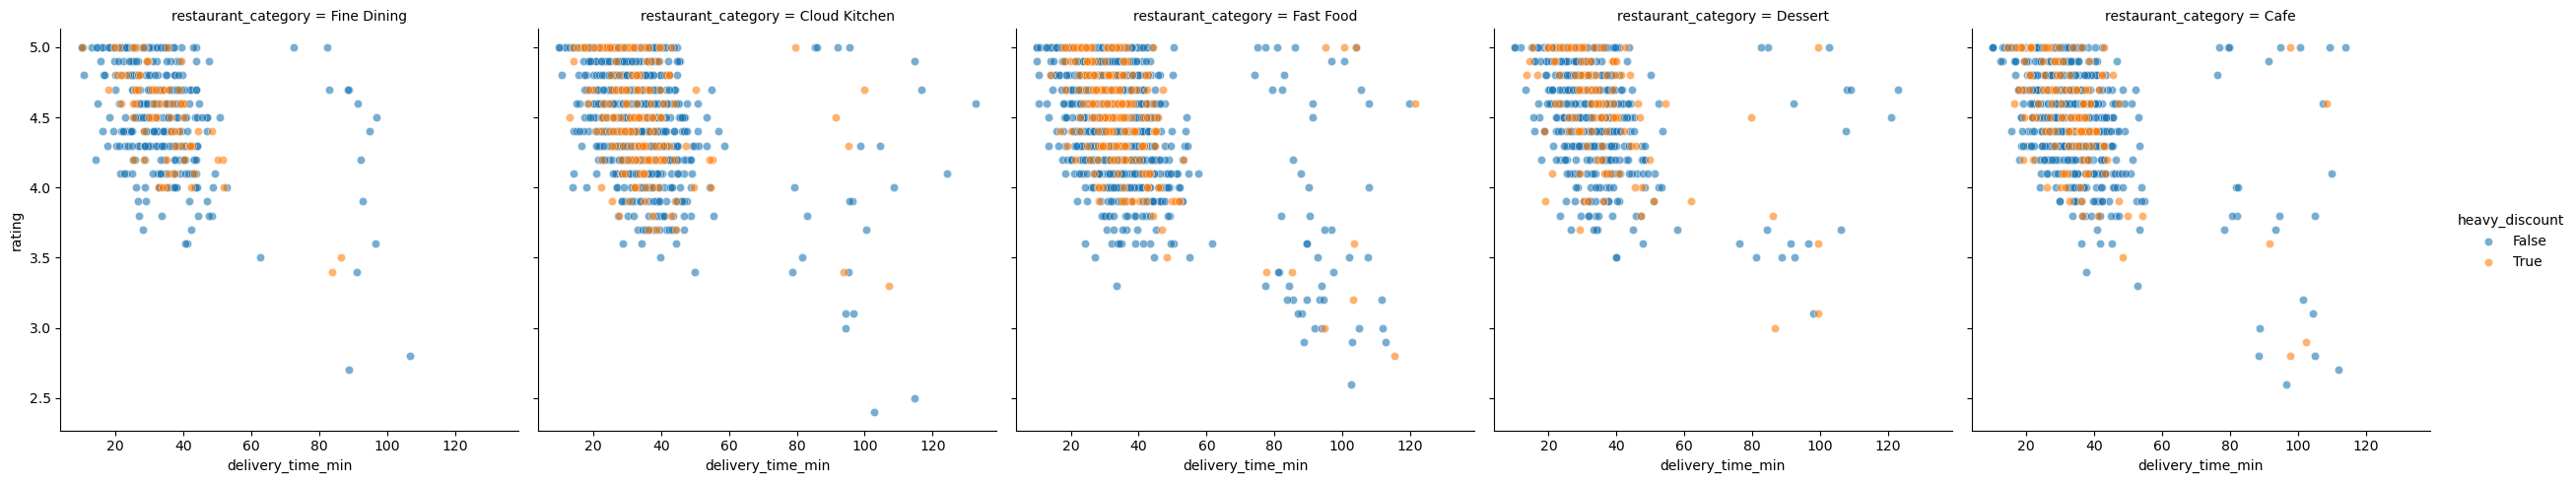

In [61]:
# task 7
df['heavy_discount'] = df['discount_percent'] > 20


g = sns.FacetGrid(
    df,
    col='restaurant_category',
    hue='heavy_discount',
    height=5
)

g.map_dataframe(
    sns.scatterplot,
    x='delivery_time_min',
    y='rating',
    alpha=0.6
)

g.add_legend()
plt.show()

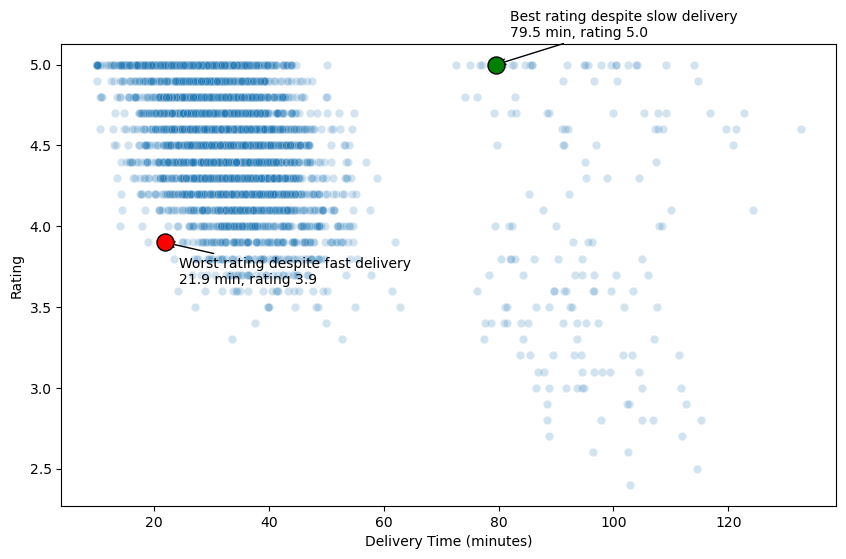

In [64]:
# task 8

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='delivery_time_min',
    y='rating',
    alpha=0.2
)

# Best rating despite unusually long delivery
best_slow = df[df['delivery_time_min'] > df['delivery_time_min'].quantile(0.90)] \
    .sort_values('rating', ascending=False).iloc[0]

# Worst rating despite unusually fast delivery
worst_fast = df[df['delivery_time_min'] < df['delivery_time_min'].quantile(0.10)] \
    .sort_values('rating').iloc[0]

# Big GREEN dot
plt.scatter(
    best_slow['delivery_time_min'],
    best_slow['rating'],
    s=150,
    color='green',
    edgecolor='black',
    zorder=5
)

# Big RED dot
plt.scatter(
    worst_fast['delivery_time_min'],
    worst_fast['rating'],
    s=150,
    color='red',
    edgecolor='black',
    zorder=5
)

# Annotations
plt.annotate(
    f"Best rating despite slow delivery\n"
    f"{best_slow['delivery_time_min']} min, rating {best_slow['rating']}",
    xy=(best_slow['delivery_time_min'], best_slow['rating']),
    xytext=(10, 20),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->')
)

plt.annotate(
    f"Worst rating despite fast delivery\n"
    f"{worst_fast['delivery_time_min']} min, rating {worst_fast['rating']}",
    xy=(worst_fast['delivery_time_min'], worst_fast['rating']),
    xytext=(10, -30),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->')
)


plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Rating')
plt.show()